# Course 1 · Week 1 — Solution: Gradient Descent

This is the **fully worked solution** to the [Week 1 exercise notebook](../exercises/course1-week1-gradient-descent.ipynb). Don't open this until you've genuinely tried — the whole point of the exercise is the struggle.

This solution explains:
- What each piece of code does, line by line
- *Why* it's written that way (and why other ways are wrong)
- What the numbers mean and why we get the values we get


## Setup — generate the data

We're going to fit a line to 10 noisy points. We *know* the true line we sampled from is `y = 2x + 5` (because we made it up), so we can check at the end whether gradient descent recovered it.

In the real world you of course don't know the true line — that's the whole point of fitting one.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible random data — DO NOT change these lines
np.random.seed(42)
m = 10  # number of training examples
X = np.linspace(0.5, 5.0, m)            # input feature (e.g. house size in 1000s of sq ft)
y_true = 2.0 * X + 5.0                  # the true line: slope 2, intercept 5
y = y_true + np.random.normal(0, 0.8, m)  # observed values with noise (e.g. price in $100k)

print(f"X = {np.round(X, 2)}")
print(f"y = {np.round(y, 2)}")


Matplotlib is building the font cache; this may take a moment.


X = [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
y = [ 6.4   6.89  8.52 10.22  9.81 10.81 13.26 13.61 13.62 15.43]


You should see 10 points roughly arranged along an upward slope, but not on a perfect line — that's the noise. Your job is to find the best straight line through this cloud.

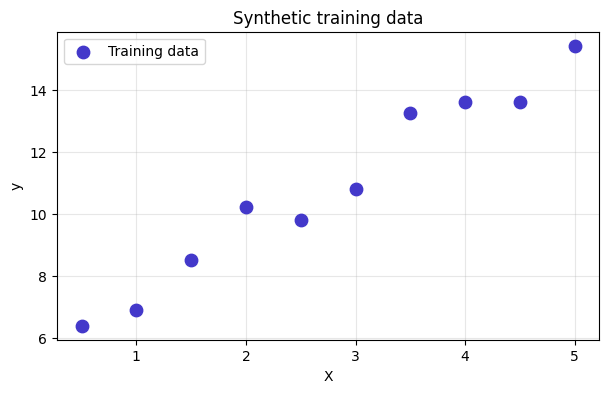

In [2]:
plt.figure(figsize=(7, 4))
plt.scatter(X, y, label="Training data", color="#4338ca", s=80, zorder=3)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic training data")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Quick recap (more depth)

We want to fit a straight line to noisy points. There are three pieces:

### The model

`f(x) = w*x + b` is the simplest possible model with a learnable shape. `w` controls slope; `b` shifts the line up or down. With these two numbers, we can describe any line in 2D.

### The cost function — why squared error?

Three reasons squared error is the standard choice for regression:

1. **It penalizes both directions.** Predicting 100 when the truth is 110 is just as bad as predicting 120 when the truth is 110. Squaring kills the sign.
2. **It punishes big misses more than small ones.** An error of 10 contributes 100 to the cost; two errors of 5 contribute only 25 each (50 total). The model is incentivized to never be way off.
3. **It's smooth and convex** — the cost surface for linear regression is shaped like a bowl, with one global minimum. Gradient descent will find it from anywhere.

The `1/2m` factor: `1/m` averages over the dataset (so the cost doesn't blow up just because you have more data); the extra `1/2` is cosmetic — when you take the derivative for gradient descent, the factor of 2 from squaring cancels the 1/2, leaving cleaner formulas.

### The optimizer — gradient descent

Imagine you're standing on a hilly landscape, blindfolded, and you want to reach the bottom. You can feel the slope under your feet. Walk a small step in the *downhill* direction. Feel again. Take another step. Repeat.

The gradient is exactly that "downhill direction" generalized to many dimensions. The learning rate `alpha` is your step size.

The math:

$$w \leftarrow w - \alpha \cdot \frac{\partial J}{\partial w}, \quad b \leftarrow b - \alpha \cdot \frac{\partial J}{\partial b}$$

Why subtract? Because the gradient points *uphill* (toward higher cost). We want to go *down*, so we subtract.


## Exercise 1 — the prediction function

```python
def predict(x, w, b):
    return w * x + b
```

That's the whole thing. Three reasons this looks anti-climatic:

1. **The math is genuinely this simple.** `f(x) = wx + b` is the equation of a line you've seen since middle school.
2. **Numpy broadcasts automatically.** When `x` is a numpy array, `w * x` multiplies each element. Then `+ b` adds the scalar to each. So the same line works for scalar inputs and array inputs.
3. **We don't need a class.** A function that takes inputs and parameters and returns predictions is enough.

The sanity check: `predict(3, 2, 1)` should return `2*3 + 1 = 7`. If it doesn't, your implementation is wrong somewhere.


In [3]:
def predict(x, w, b):
    """Compute the linear model: f(x) = w*x + b.

    Args:
        x: a single number, or a numpy array of inputs.
        w: scalar — the weight (slope).
        b: scalar — the bias (intercept).

    Returns:
        Same shape as x — the predicted values.
    """
    return w * x + b


# Sanity check
print(f"predict(3.0, 2.0, 1.0) = {predict(3.0, 2.0, 1.0)}")
assert abs(predict(3.0, 2.0, 1.0) - 7.0) < 1e-9
print("✓ predict() works")


predict(3.0, 2.0, 1.0) = 7.0
✓ predict() works


## Exercise 2 — the cost function

```python
def cost(X, y, w, b):
    yhat = predict(X, w, b)
    errors = yhat - y
    return float(np.mean(errors ** 2) / 2)
```

Step-by-step:

- `predict(X, w, b)` computes the predicted `y` for every input in `X` — produces a length-10 array.
- `yhat - y` is element-wise subtraction — also length 10. Each entry is the error for one example.
- `errors ** 2` squares each entry. Negative errors become positive; big errors become much bigger.
- `np.mean(...)` averages all squared errors → one scalar.
- `/2` is the cosmetic factor that makes the gradient formulas cleaner.
- `float(...)` is just to ensure the return is a plain Python float, not a numpy scalar (small ergonomic detail).

**Why the test values?**

`cost(X, y, 0, 0) ≈ 63.18` — when `w=0, b=0`, the model predicts 0 everywhere. The errors are just `0 - y = -y`, and squared they're `y^2`. The average of `y^2` (divided by 2) gives 63.18 for our dataset.

`cost(X, y, 2, 5) ≈ 0.21` — almost zero, because `(w=2, b=5)` is extremely close to the true line `y = 2x + 5` we sampled from. The remaining cost is just the noise we added.


In [4]:
def cost(X, y, w, b):
    """Squared-error cost J(w, b) = (1/2m) * sum((f(x_i) - y_i)^2)."""
    yhat = predict(X, w, b)              # vector of predictions
    errors = yhat - y                    # vector of errors
    return float(np.mean(errors ** 2) / 2)


J_zero = cost(X, y, 0.0, 0.0)
J_good = cost(X, y, 2.0, 5.0)
print(f"cost at (w=0, b=0) = {J_zero:.4f}")
print(f"cost at (w=2, b=5) = {J_good:.4f}")
assert abs(J_zero - 63.1830) < 0.01
assert abs(J_good - 0.2148) < 0.01
print("✓ cost() works")


cost at (w=0, b=0) = 63.1830
cost at (w=2, b=5) = 0.2148
✓ cost() works


## Exercise 3 — the gradients

```python
def gradients(X, y, w, b):
    yhat = predict(X, w, b)
    err = yhat - y
    dw = float(np.mean(err * X))
    db = float(np.mean(err))
    return dw, db
```

The math says:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum (f(x_i) - y_i) x_i \qquad \frac{\partial J}{\partial b} = \frac{1}{m} \sum (f(x_i) - y_i)$$

Code translation:

- `err = yhat - y` — vector of errors (same as before).
- `err * X` — element-wise multiplication; gives a vector where each entry is the error for example `i` times its `x_i`.
- `np.mean(err * X)` — average → `dw`.
- `np.mean(err)` — unweighted average error → `db`.

**Intuition for the derivative form:**

`dJ/dw` is *signed*. If predictions are systematically too high (`yhat > y`), errors are positive, and `dw` is positive — meaning "if you increase `w`, cost goes up, so go the other way." Gradient descent then subtracts a positive number and decreases `w`. Self-correcting.

**Test value:** at `(w=0, b=0)`, the model predicts 0 everywhere, so the errors are `-y` (large negative numbers since `y` is positive). The gradient is the average of `(-y)*x`, which is negative. We computed `dw ≈ -33.96`. After `w := 0 - 0.05 * (-33.96) = +1.7`, `w` jumps from 0 toward 2 — the right direction.


In [5]:
def gradients(X, y, w, b):
    """Partial derivatives of J w.r.t. w and b."""
    yhat = predict(X, w, b)
    err = yhat - y
    dw = float(np.mean(err * X))   # element-wise multiply, then average
    db = float(np.mean(err))
    return dw, db


dw0, db0 = gradients(X, y, 0.0, 0.0)
print(f"At (w=0, b=0): dw = {dw0:.4f}, db = {db0:.4f}")
assert abs(dw0 - (-33.9630)) < 0.01
assert abs(db0 - (-10.8584)) < 0.01
print("✓ gradients() works")


At (w=0, b=0): dw = -33.9630, db = -10.8584
✓ gradients() works


## Exercise 4 — gradient descent itself

```python
def gradient_descent(X, y, w_init, b_init, alpha, n_iters):
    w, b = w_init, b_init
    history = []
    for i in range(n_iters):
        dw, db = gradients(X, y, w, b)   # compute BOTH from current (w, b)
        w = w - alpha * dw                # then update BOTH
        b = b - alpha * db
        history.append(cost(X, y, w, b))
    return w, b, history
```

The simultaneous update is non-negotiable. If you write:

```python
w = w - alpha * dw
db = ...gradient using NEW w...   # ← wrong
b = b - alpha * db
```

…you've changed the algorithm. The new gradient is computed against a partly-updated state. The new algorithm has different convergence properties (often worse) and is *not* gradient descent. Always: compute both derivatives, *then* apply both updates.

**What the numbers mean:**

After 1000 iterations starting from `(0, 0)` with `alpha=0.05`, we get `w ≈ 1.99, b ≈ 5.39`. The true line was `y = 2x + 5`, but we added noise to each `y` — so the best line is *slightly* off from the truth (by about 0.4 in the intercept). That's not a bug; that's noise leaking through, which is unavoidable. Cost gets stuck near 0.15 — that's the variance of the noise we injected.

The cost-vs-iterations plot drops fast in the first 50 iterations, then slows dramatically. That's typical: gradient descent gets you 90% of the way there in the first few percent of iterations, and the rest is fine-tuning.


In [6]:
def gradient_descent(X, y, w_init, b_init, alpha, n_iters):
    """Run gradient descent for n_iters steps.

    At each step, compute both gradients FIRST (from the current w, b),
    THEN apply both updates. This is the simultaneous-update rule.
    """
    w, b = w_init, b_init
    history = []
    for i in range(n_iters):
        dw, db = gradients(X, y, w, b)   # compute from current (w, b)
        w = w - alpha * dw                # update simultaneously
        b = b - alpha * db
        history.append(cost(X, y, w, b))
    return w, b, history


w_final, b_final, hist = gradient_descent(X, y, w_init=0.0, b_init=0.0, alpha=0.05, n_iters=1000)
print(f"After 1000 iterations with alpha=0.05:")
print(f"  w = {w_final:.4f}")
print(f"  b = {b_final:.4f}")
print(f"  final cost = {hist[-1]:.4f}")

# True line was y = 2x + 5; we recovered w≈2, b≈5 from noisy data — that's the goal.
assert abs(w_final - 1.989) < 0.05
assert abs(b_final - 5.389) < 0.05
print("✓ Recovered the true line within noise tolerance")


After 1000 iterations with alpha=0.05:
  w = 1.9890
  b = 5.3886
  final cost = 0.1504
✓ Recovered the true line within noise tolerance


## Visualize

The two charts tell the story:

- **Cost decreasing** — the optimizer is working. If your line in this plot didn't go down, your gradients are wrong.
- **Final fit** — the green line is your model after training. It should run through the cloud of points. The match isn't perfect because of noise, but the slope and offset are right.


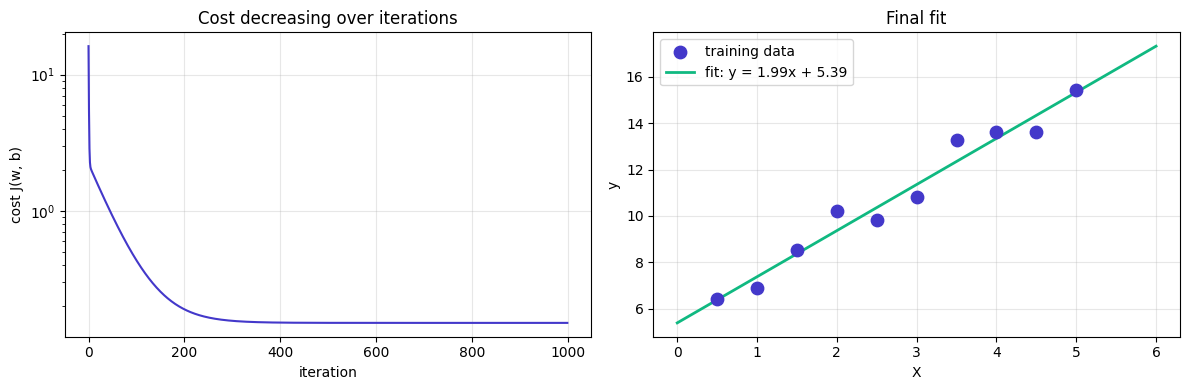

In [7]:
# Plot the cost trajectory and the final fitted line
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cost over iterations
axes[0].plot(hist, color="#4338ca")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("cost J(w, b)")
axes[0].set_title("Cost decreasing over iterations")
axes[0].set_yscale("log")
axes[0].grid(alpha=0.3)

# Data + fitted line
xs = np.linspace(0, 6, 100)
axes[1].scatter(X, y, color="#4338ca", s=80, zorder=3, label="training data")
axes[1].plot(xs, predict(xs, w_final, b_final), color="#10b981", lw=2, label=f"fit: y = {w_final:.2f}x + {b_final:.2f}")
axes[1].set_xlabel("X")
axes[1].set_ylabel("y")
axes[1].set_title("Final fit")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## ⭐ Stretch goal — the learning rate

```python
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
for alpha in alphas:
    w, b, hist = gradient_descent(X, y, 0.0, 0.0, alpha, 1000)
    print(f"alpha={alpha}: final cost {hist[-1]}")
```

Expected results for our dataset:

| alpha | result | what's happening |
|---|---|---|
| 0.001 | converged but didn't finish — w ≈ 3.05, b ≈ 1.75, cost ≈ 1.57 | step is tiny, 1000 iterations isn't enough |
| 0.01 | almost there — w ≈ 2.17, b ≈ 4.78, cost ≈ 0.19 | reasonable, still converging |
| 0.1 | converged — w ≈ 1.99, b ≈ 5.39, cost ≈ 0.15 | fast and stable, classic Goldilocks zone |
| 1.0 | **diverged** — `nan` | step too big, oscillating into infinity |
| 10.0 | **diverged** — `nan` | even more so |

The lesson: too small `alpha` = wasted compute. Too large = the algorithm explodes. The first thing to try if cost goes up across iterations? Cut `alpha` by 3×. The first thing to try if cost crawls? Multiply `alpha` by 3×. Most production systems use values between `0.001` and `0.1`.


In [8]:
# STRETCH: try several learning rates
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]

print(f"{'alpha':>8}  {'final w':>10}  {'final b':>10}  {'final cost':>14}  status")
print("-" * 60)
for alpha in alphas:
    w, b, hist = gradient_descent(X, y, 0.0, 0.0, alpha, 1000)
    final_cost = hist[-1]
    status = "diverged ❌" if not np.isfinite(final_cost) or final_cost > 1e6 else "converged ✓"
    if np.isfinite(final_cost) and final_cost < 1e6:
        print(f"{alpha:>8}  {w:>10.4f}  {b:>10.4f}  {final_cost:>14.4f}  {status}")
    else:
        print(f"{alpha:>8}  {'inf':>10}  {'inf':>10}  {'inf':>14}  {status}")


   alpha     final w     final b      final cost  status
------------------------------------------------------------
   0.001      3.0496      1.7526          1.5693  converged ✓
    0.01      2.1675      4.7769          0.1906  converged ✓
     0.1      1.9890      5.3888          0.1504  converged ✓
     1.0         inf         inf             inf  diverged ❌
    10.0         inf         inf             inf  diverged ❌


/var/folders/pt/0xz_dn494tqcl271q4_v4dzr0000gn/T/ipykernel_97282/1745655747.py:5: RuntimeWarning: overflow encountered in square
  return float(np.mean(errors ** 2) / 2)
/Users/waytan/.pyenv/versions/3.11.11/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


## Wrap-up

What you just built is the same code structure used in:

- **Logistic regression** (next week) — same gradient descent, but with a sigmoid in `predict` and log-loss in `cost`.
- **Neural networks** (Course 2) — same gradient descent, but `predict` becomes many layers of matrix multiplications and the gradients are computed by backprop.
- **Transformers** (Course 4) — same gradient descent at the core, just with billions of parameters and clever architectural pieces.

Every modern ML system runs gradient descent (or a variant like Adam) on a parameterized model with a cost function. Understanding it from 30 lines of code is the most leveraged thing you can learn this week.

Onward to [Week 2](../exercises/course1-week2-multivariate.ipynb).
